<a href="https://colab.research.google.com/github/2d-game-dev/ComputerVisionProject/blob/main/NEWERVersionOFCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ce2bdqFeT7e9MGJbnEPa")
project = rf.workspace("my-workspace-y2ace").project("cctv-naxyo-drk6y")
dataset = project.version(1).download("yolov5")

loading Roboflow workspace...
loading Roboflow project...


In [58]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

In [59]:
class GridDataset(Dataset):
    def __init__(self, images_path, labels_path, grid_size=7, max_images=1000):
        self.images = []
        self.labels = []
        self.grid_size = grid_size

        img_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png'))]

        for img_file in img_files[:max_images]:
            label_file = img_file.replace('.jpg', '.txt').replace('.png', '.txt')
            label_path = os.path.join(labels_path, label_file)

            grid = np.zeros((grid_size, grid_size, 5))  # [conf, x, y, w, h]

            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    for line in f.readlines():
                        parts = line.strip().split()
                        if len(parts) == 5:
                            _, x, y, w, h = map(float, parts)

                            gx = int(x * grid_size)
                            gy = int(y * grid_size)

                            if gx < grid_size and gy < grid_size:
                                grid[gy, gx] = [1, x, y, w, h]

            self.images.append(os.path.join(images_path, img_file))
            self.labels.append(grid)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        img = img.resize((224, 224))
        img = np.array(img) / 255.0
        img = torch.FloatTensor(img).permute(2, 0, 1)

        label = torch.FloatTensor(self.labels[idx])
        return img, label

In [60]:
class GridDetectionModel(nn.Module):
    def __init__(self, grid_size=7):
        super().__init__()
        self.grid_size = grid_size

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.fc = nn.Linear(128 * 14 * 14, 1024)
        self.output = nn.Linear(1024, grid_size * grid_size * 5)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc(x))
        x = self.output(x)
        x = x.view(-1, self.grid_size, self.grid_size, 5)

         # ✅ Apply activations
        x[..., 0] = torch.sigmoid(x[..., 0])   # confidence (0–1)
        x[..., 1:] = torch.sigmoid(x[..., 1:]) # bbox normalized (0–1)

        return x

In [61]:
def detection_loss(pred, target):
    obj_mask = target[..., 0] > 0

    loss_conf = ((pred[..., 0] - target[..., 0]) ** 2).mean()

    if obj_mask.sum() > 0:
        loss_bbox = ((pred[obj_mask][..., 1:] - target[obj_mask][..., 1:]) ** 2).mean()
    else:
        loss_bbox = 0

    return loss_conf + loss_bbox

In [62]:
dataset_path = "/content/cctv-1"

train_dataset = GridDataset(f"{dataset_path}/train/images", f"{dataset_path}/train/labels")
val_dataset = GridDataset(f"{dataset_path}/valid/images", f"{dataset_path}/valid/labels")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GridDetectionModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.003)

epochs = 25
train_losses = []
val_losses = []

for epoch in range(epochs):
    # ── Train ──────────────────────────────────────────────────
    model.train()
    total_loss = 0
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, targets = images.to(device), targets.to(device)
        preds = model(images)
        loss  = detection_loss(preds, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation loss ────────────────────────────────────────
    model.eval()
    val_total = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(device), targets.to(device)
            preds    = model(images)
            val_loss = detection_loss(preds, targets)
            val_total += val_loss.item()

    avg_val_loss = val_total / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}")

torch.save(model.state_dict(), "intrusion_model.pth")
print("Model saved ✓")

Epoch 1/25: 100%|██████████| 63/63 [01:39<00:00,  1.58s/it]


Epoch 01/25 | Train Loss: 0.0799 | Val Loss: 0.0613


Epoch 2/25: 100%|██████████| 63/63 [01:33<00:00,  1.49s/it]


Epoch 02/25 | Train Loss: 0.0683 | Val Loss: 0.0616


Epoch 3/25: 100%|██████████| 63/63 [01:35<00:00,  1.51s/it]


...

Epoch 23/25 | Train Loss: 0.0090 | Val Loss: 0.0590


Epoch 24/25: 100%|██████████| 63/63 [01:47<00:00,  1.71s/it]


Epoch 24/25 | Train Loss: 0.0083 | Val Loss: 0.0597


Epoch 25/25: 100%|██████████| 63/63 [01:46<00:00,  1.69s/it]


Epoch 25/25 | Train Loss: 0.0077 | Val Loss: 0.0580
Model saved ✓


  Validation Accuracy : 89.9%
  MSE  (confidence)   : 0.0472
  RMSE (confidence)   : 0.2174
  Accuracy = % of images where the model correctly
             predicted person-present or person-absent
  MSE/RMSE = average error in confidence score prediction
             (lower is better, 0.0 would be perfect)


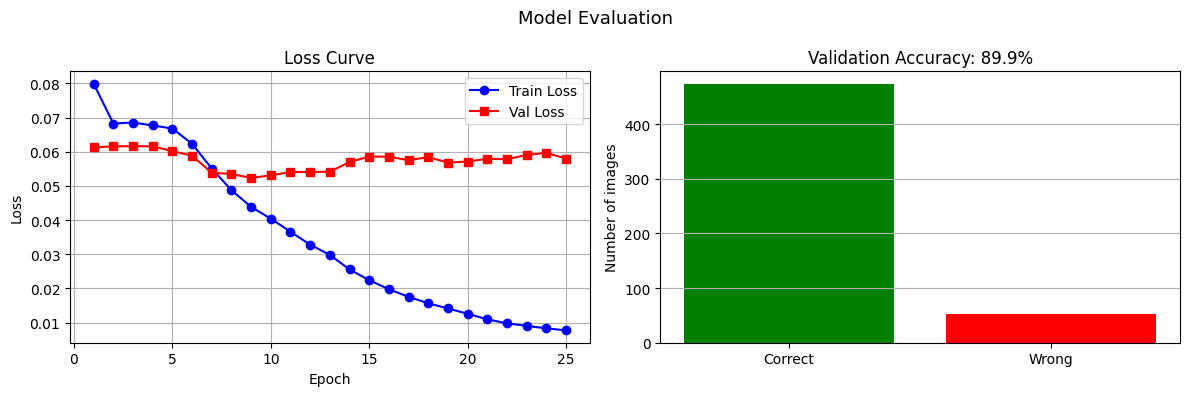

In [64]:
# ── Loss curves ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, epochs+1), train_losses, 'b-o', label='Train Loss')
ax1.plot(range(1, epochs+1), val_losses,   'r-s', label='Val Loss')
ax1.set_title("Loss Curve"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(True)

# ── Accuracy + MSE + RMSE on validation set ───────────────────
model.eval()
correct   = 0
total     = 0
mse_total = 0.0

with torch.no_grad():
    for images, targets in val_loader:
        images, targets = images.to(device), targets.to(device)
        preds = model(images)

        # Accuracy: did the model correctly predict person-present / person-absent?
        pred_has_person = preds[..., 0].amax(dim=(1,2))  > 0.3   # bool per image
        true_has_person = targets[..., 0].amax(dim=(1,2)) > 0.0   # bool per image
        correct += (pred_has_person == true_has_person).sum().item()
        total   += images.size(0)

        # MSE on confidence scores across all grid cells
        mse_total += ((preds[..., 0] - targets[..., 0]) ** 2).mean().item()

accuracy = 100 * correct / total
mse      = mse_total / len(val_loader)
rmse     = mse ** 0.5

print("=" * 40)
print(f"  Validation Accuracy : {accuracy:.1f}%")
print(f"  MSE  (confidence)   : {mse:.4f}")
print(f"  RMSE (confidence)   : {rmse:.4f}")
print("=" * 40)
print("  Accuracy = % of images where the model correctly")
print("             predicted person-present or person-absent")
print("  MSE/RMSE = average error in confidence score prediction")
print("             (lower is better, 0.0 would be perfect)")

# ── Accuracy bar chart ─────────────────────────────────────────
ax2.bar(["Correct", "Wrong"],
        [correct, total - correct],
        color=["green", "red"])
ax2.set_title(f"Validation Accuracy: {accuracy:.1f}%")
ax2.set_ylabel("Number of images")
ax2.grid(axis='y')

plt.suptitle("Model Evaluation", fontsize=13)
plt.tight_layout()
plt.show()

In [65]:
def detect_intrusion(model, image_path, restricted_zone=[0.3,0.4,0.7,0.6], threshold=0.1):
    model.eval()

    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((224,224))
    img_tensor = torch.FloatTensor(np.array(img_resized)/255.0).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor)[0].cpu().numpy()

    print("Max confidence:", pred[...,0].max())

    intrusion = False
    boxes = []

    for i in range(pred.shape[0]):
        for j in range(pred.shape[1]):
            conf = pred[i,j,0]

            if conf > threshold:
                x, y, w, h = pred[i,j,1:]
                boxes.append((x,y,w,h))

                # ✅ NEW: box-overlap intrusion check
                # Box corners
                x1 = x - w/2
                y1 = y - h/2
                x2 = x + w/2
                y2 = y + h/2

                # Zone
                zx1, zy1, zx2, zy2 = restricted_zone

                # Check overlap
                if (x1 < zx2 and x2 > zx1 and y1 < zy2 and y2 > zy1):
                    intrusion = True

    # Visualization
    fig, ax = plt.subplots(1)
    ax.imshow(img)

    h_img, w_img = img.size[1], img.size[0]

    # Draw restricted zone
    rz = patches.Rectangle((restricted_zone[0]*w_img, restricted_zone[1]*h_img),
                           (restricted_zone[2]-restricted_zone[0])*w_img,
                           (restricted_zone[3]-restricted_zone[1])*h_img,
                           edgecolor='red', facecolor='red', alpha=0.3)
    ax.add_patch(rz)

    # Draw boxes
    for (x,y,w,h) in boxes:
        rect = patches.Rectangle(((x-w/2)*w_img,(y-h/2)*h_img),
                                 w*w_img,h*h_img,
                                 edgecolor='yellow', facecolor='none')
        ax.add_patch(rect)

    if intrusion:
        plt.title("🚨 INTRUSION DETECTED", color="red")
    else:
        plt.title("✅ SAFE")

    plt.axis('off')
    plt.show()

    return intrusion

Max confidence: 0.21566097


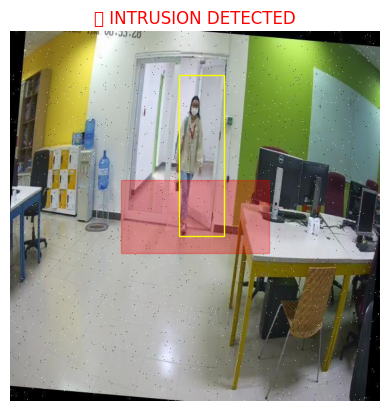

True

In [66]:
test_image = val_dataset.images[0]
detect_intrusion(model, test_image)

Frame 1: 00032_jpg.rf.ad905582545d5429850935be93e2bea0.jpg
Max confidence: 0.029662076


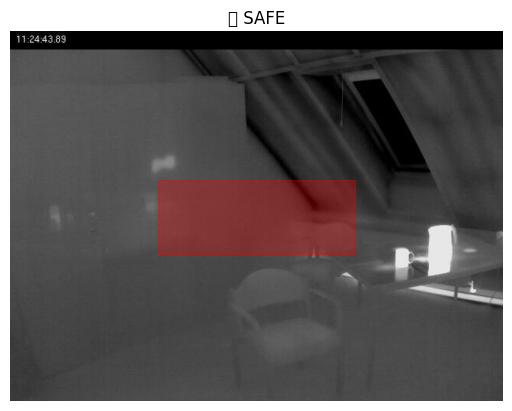

  -> Clear
Frame 2: 00198_jpg.rf.20e35180c9b1bab837bf2a7cfbd7588a.jpg
Max confidence: 0.025866084


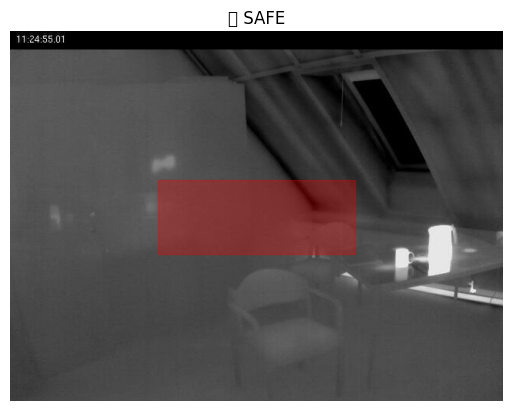

  -> Clear
Frame 3: 00325_jpg.rf.60384ab03a1aa456a4ea8c57e07ad48a.jpg
Max confidence: 0.6020954


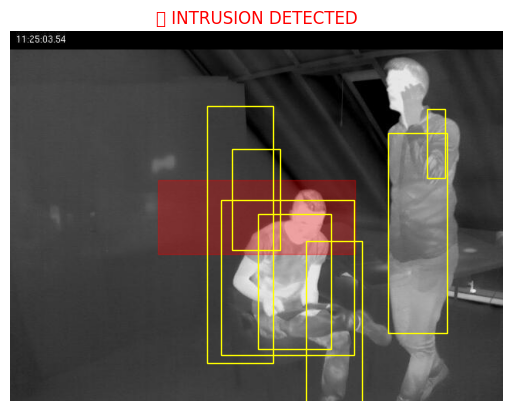

  -> INTRUSION
Frame 4: 00335_jpg.rf.a1abdcfa909cb3e40b49b17e39626fa0.jpg
Max confidence: 0.85748714


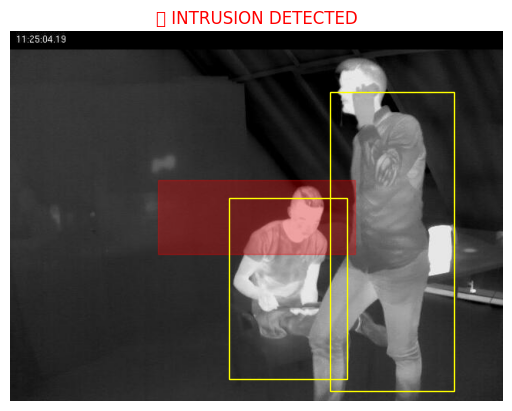

  -> INTRUSION
Frame 5: 00355_jpg.rf.5654a8d988ae0396c8e3c7f3acebd3e1.jpg
Max confidence: 0.46937647


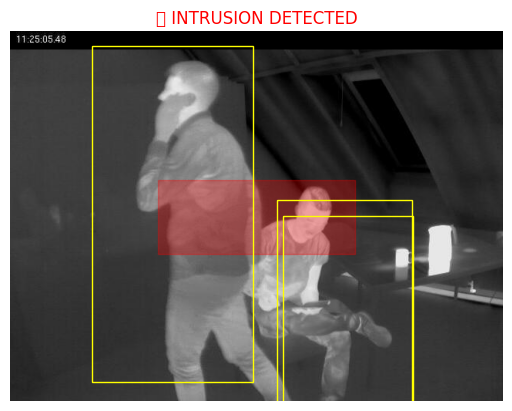

  -> INTRUSION
Frame 6: 00398_jpg.rf.56678498da62b969355fc30dc05ed2e3.jpg
Max confidence: 0.7008467


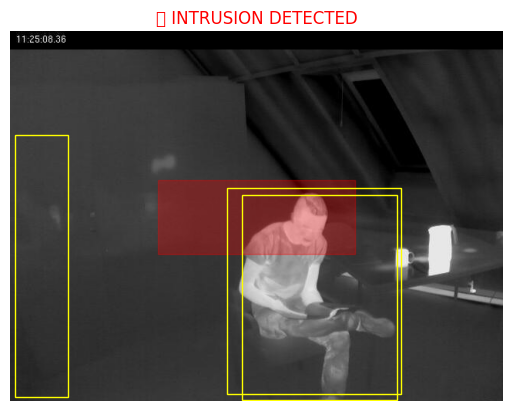

  -> INTRUSION
Frame 7: 00427_jpg.rf.e87b12ddb5da57794577c7fcb572f7b3.jpg
Max confidence: 0.6945132


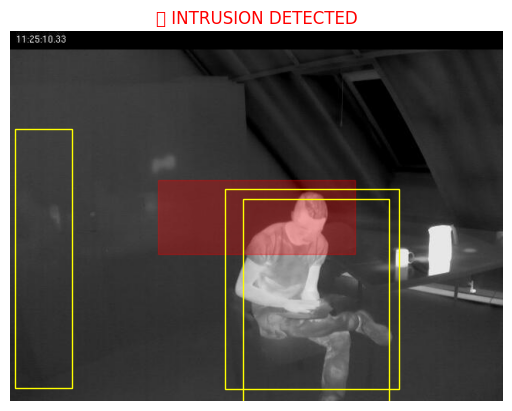

  -> INTRUSION
Frame 8: 00521_jpg.rf.fe5379cb1b4688b33d3d609b783be428.jpg
Max confidence: 0.7819621


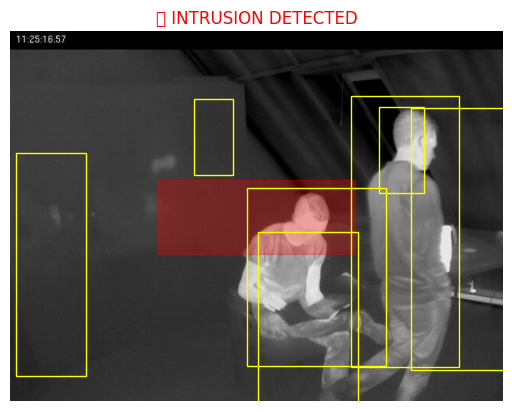

  -> INTRUSION
Frame 9: 00535_jpg.rf.257df837997c34823e5b8863830c7081.jpg
Max confidence: 0.8802797


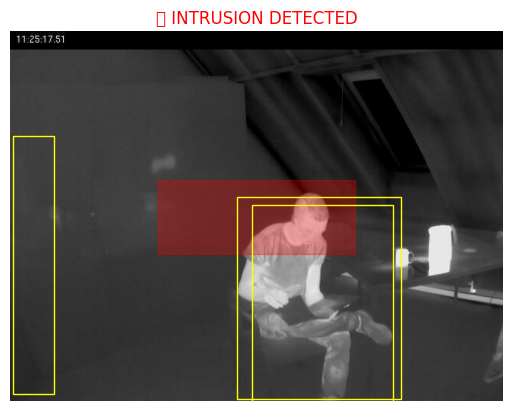

  -> INTRUSION
Frame 10: 00549_jpg.rf.b05058373e852c6879dfc45c71501a59.jpg
Max confidence: 0.7889055


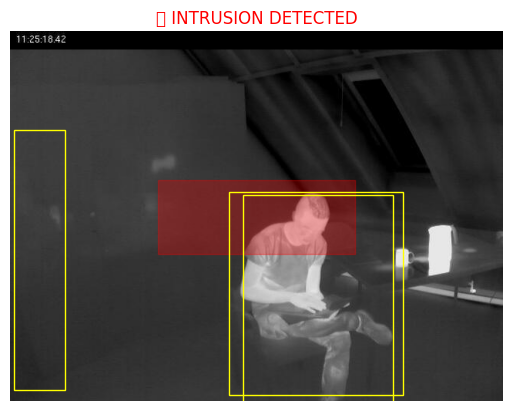

  -> INTRUSION
Frame 11: 00552_jpg.rf.09f6cdc6dde15bc88e8b0bfae5dacb41.jpg
Max confidence: 0.7529093


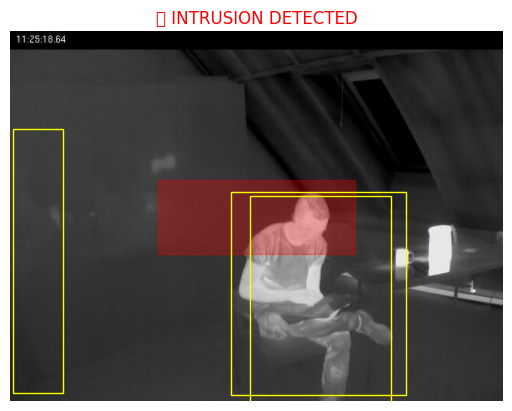

  -> INTRUSION
Frame 12: 00698_jpg.rf.db144bd423f0b873b3ab4a58a96d7584.jpg
Max confidence: 0.95816195


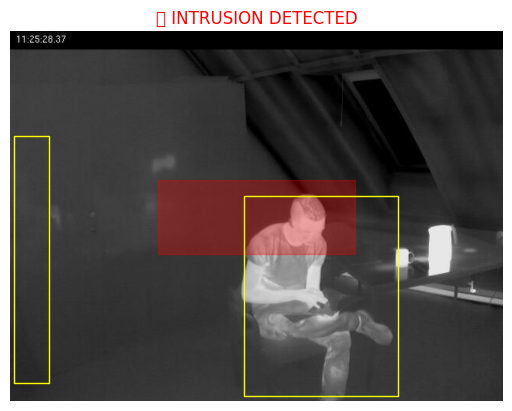

  -> INTRUSION
Frame 13: 00789_jpg.rf.167d928bb857dc3fb0aef9a5c0e1890b.jpg
Max confidence: 0.9472187


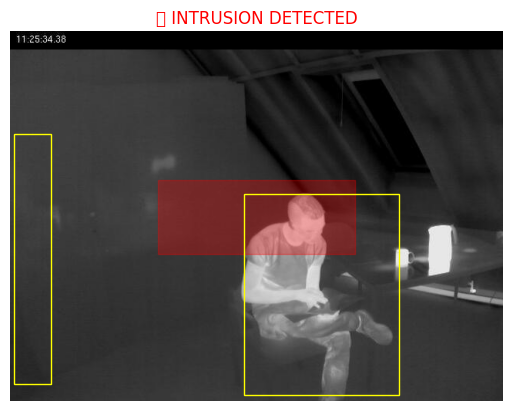

  -> INTRUSION
Frame 14: 00798_jpg.rf.23f5895bfb03585fe4e5cd1dfad5a594.jpg
Max confidence: 0.6881141


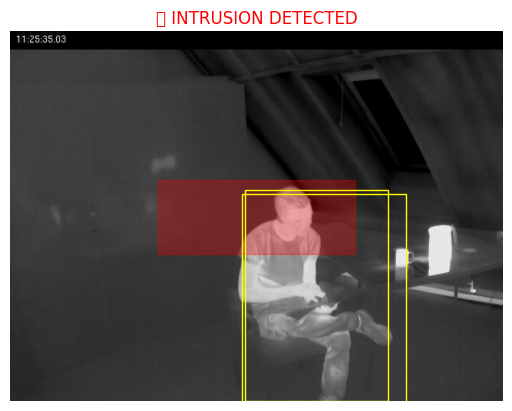

  -> INTRUSION
Frame 15: 00825_jpg.rf.5d495cc85482f0aa9a3ae4c8f3e0b0e3.jpg
Max confidence: 0.9772917


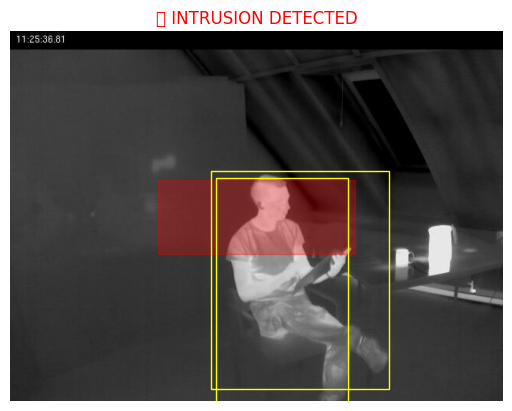

  -> INTRUSION
Frame 16: 00917_jpg.rf.5b33227961a2d26782604454fa2b8127.jpg
Max confidence: 0.982297


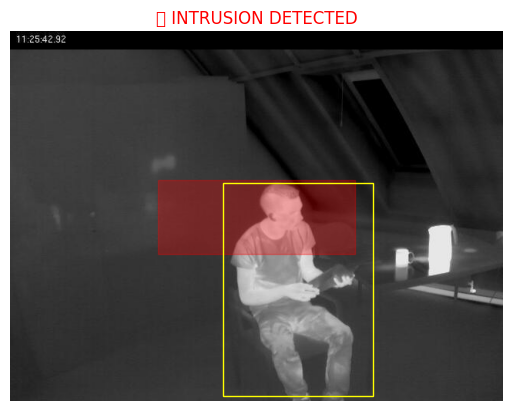

  -> INTRUSION
Frame 17: 00930_jpg.rf.60c27d08fd667a4699f91662ea75b326.jpg
Max confidence: 0.98654556


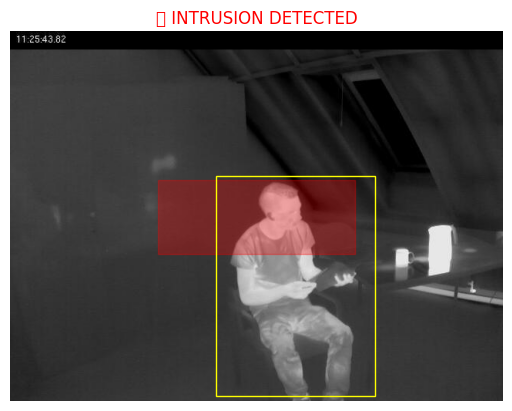

  -> INTRUSION
Frame 18: 00943_jpg.rf.2c59fcc74e2a85fce000cb8693df4e99.jpg
Max confidence: 0.98911124


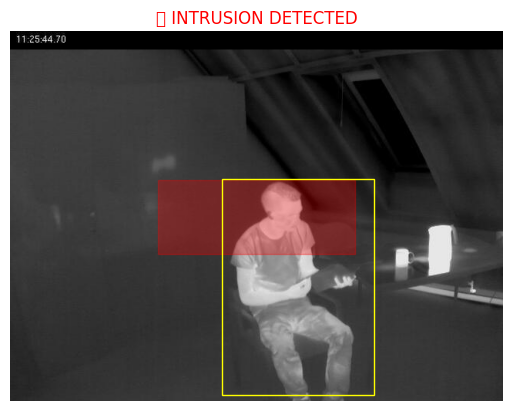

  -> INTRUSION
Frame 19: 00944_jpg.rf.dfcdef310fa67e347119f63efbef8c5a.jpg
Max confidence: 0.9890904


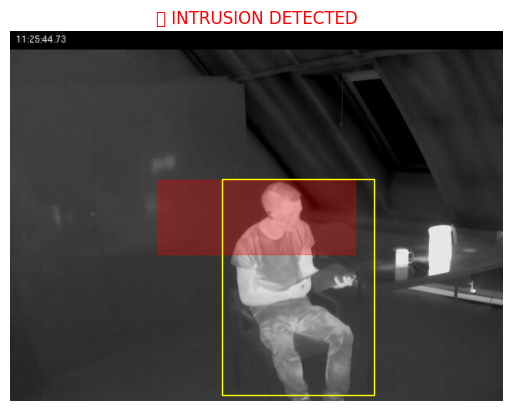

  -> INTRUSION
Frame 20: 00954_jpg.rf.c80b0b8ce4c3843f4632e5f38f76482c.jpg
Max confidence: 0.98356426


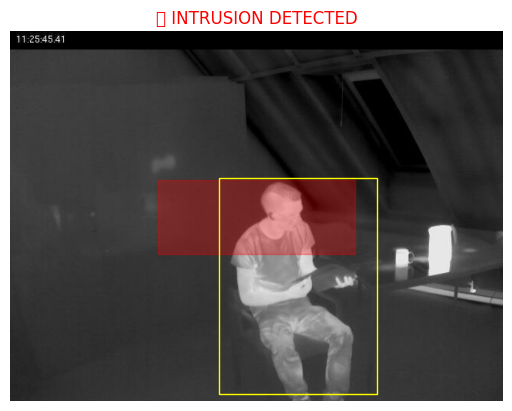

  -> INTRUSION

Summary: 18/20 frames had intrusions


In [68]:
def simulate_cctv(model, folder, max_frames=20):
    images     = sorted([f for f in os.listdir(folder)
                         if f.endswith(('.jpg', '.png', '.jpeg'))])
    intrusions = 0

    for i, img_file in enumerate(images[:max_frames]):
        print(f"Frame {i+1}: {img_file}")
        result    = detect_intrusion(model, os.path.join(folder, img_file))
        intrusions += int(result)
        print("  -> INTRUSION" if result else "  -> Clear")

    print(f"\nSummary: {intrusions}/{max_frames} frames had intrusions")

simulate_cctv(model, os.path.dirname(val_dataset.images[0]))